# Requirements
## Description
A new world organization has just been created. It includes all the museum management committees that have more than 2,000,000 visitors annually. This list is available via __[Wikipedia](https://en.wikipedia.org/wiki/List_of_most_visited_museums)__
This new organization wishes to correlate the tourist attendance at their museums with the population of the respective cities. To achieve this, a small, common and harmonized database must be built to be able to extract features. This DB must include the characteristics of museums as well as the population of the cities in which they are located. You have been chosen to build this database. In addition, you are asked to create a small linear regression ML algorithm to correlate the city population and the influx of visitors.  Your solution must balance the need for quickly assessing the data, rapid prototyping and deploying a MVP to a (potentially) public user that could later scale. You must use the Wikipedia APIs to retrieve this list of museums and their characteristics. You are free to choose the source of your choice for the population of the cities concerned.

## Deliverables
- It is required that your code is a structured Python project. The code should be packaged and exposed in a Docker container (use Docker Compose if you require additional infrastructure).
- A jupyter notebook hosted in docker should also be created. This notebook should  programmatically use your other code to visually present the results of your regression model.

## Notes
You will be evaluated not only on how your code works but also on the rationale for the choices you make. you make. 

# Workplan
1. Setup Jupyter server
2. Investigate wikipedia Python API
3. Implement a simple wrapper for fetching the required data into CSV files
4. Choose a "database" or simple CSV file
5. Implement a way to incrementally add to CSV file
6. Implement a simple script to reload the CSV file
7. Implement a simple ML regression algorithm that learns and saves the parameters
8. Implement a simple ML script that evaluates a value
9. Setup Docker

# Execution


## Set the device

In [31]:
import torch
dtype = torch.float
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Platform running on {device} device")


Platform running on cuda device


In [141]:
import importlib
import museums
import matplotlib.pyplot as plt
importlib.reload(museums)

<module 'museums' from '/home/bartosz/git/challenge/src/museums.py'>

In [142]:
museums.download_data()
museums.create_master_data()


-------------------------------
Getting page List_of_most-visited_museums, section 1 from Wikipedia
1 Downloading
2 Extracting content
3 Parsing content
Getting page List_of_largest_cities, section 5 from Wikipedia
1 Downloading
2 Extracting content
3 Parsing content

Done

Creating master data
--------------------

Done


In [147]:
museums.create_model()
museums.train_model(threshold=000000, test_ratio=0)


Creating model
--------------
Model parameters
LinearRegression(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
  (loss_fn): L1Loss()
)
Device: cuda:0
Model state
OrderedDict([('linear_layer.weight', tensor([[-0.7574]], device='cuda:0', dtype=torch.float64)), ('linear_layer.bias', tensor([-0.4741], device='cuda:0', dtype=torch.float64))])

Done

Training
--------
Parameters: s: 71, e: 20000, r:0%
Epoch: 0 | Train loss: 0.8004598204442533 | Test loss: N/A 
Epoch: 2000 | Train loss: 0.5880154118427107 | Test loss: N/A 
Epoch: 4000 | Train loss: 0.375571003241161 | Test loss: N/A 
Epoch: 6000 | Train loss: 0.2027373259913142 | Test loss: N/A 
Epoch: 8000 | Train loss: 0.16150298178607553 | Test loss: N/A 
Epoch: 10000 | Train loss: 0.15320977004468125 | Test loss: N/A 
Epoch: 12000 | Train loss: 0.1488651553856892 | Test loss: N/A 
Epoch: 14000 | Train loss: 0.1454286194765602 | Test loss: N/A 
Epoch: 16000 | Train loss: 0.14226730590145795 | Test loss: N/A 
Epoch: 18

ConversionError: Failed to convert value(s) to axis units: array([array(0.80045982), array(0.58801541), array(0.375571),
       array(0.20273733), array(0.16150298), array(0.15320977),
       array(0.14886516), array(0.14542862), array(0.14226731),
       array(0.13923089)], dtype=object)

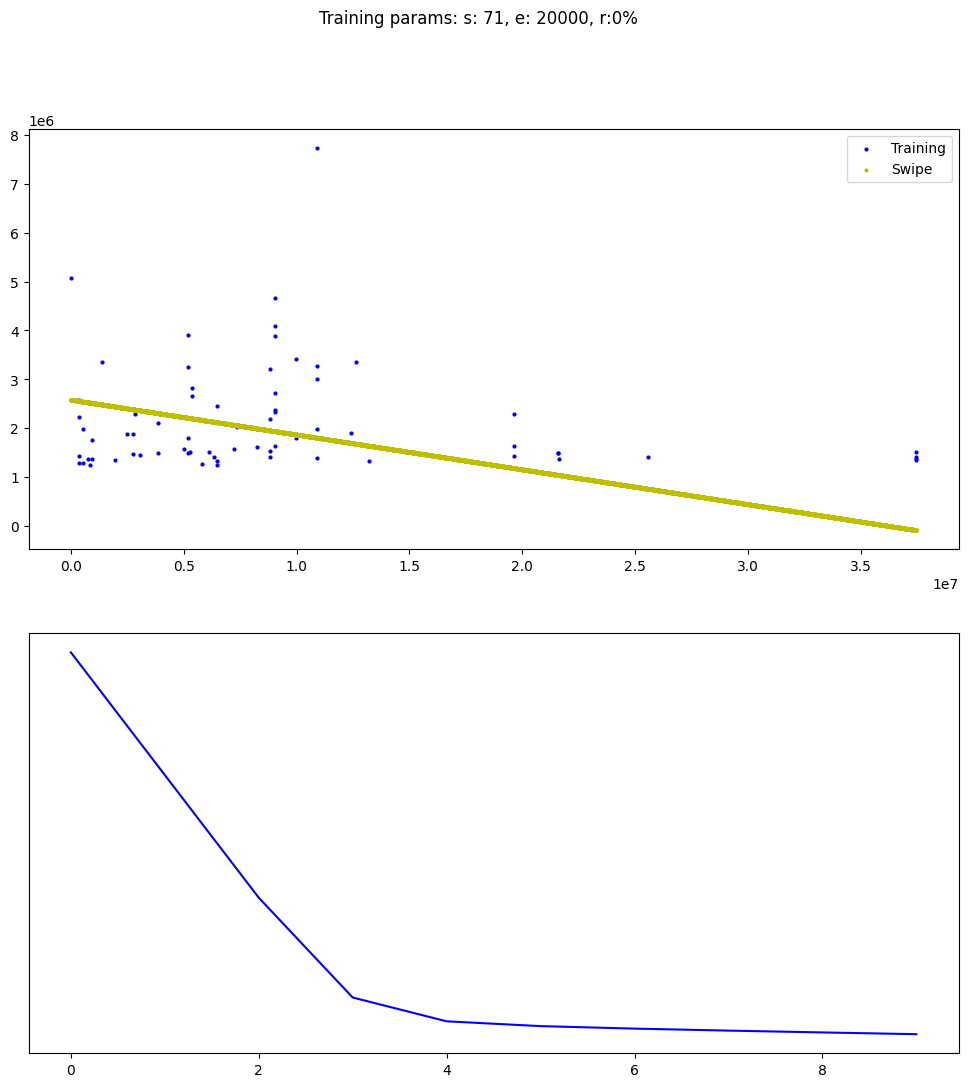

In [148]:
museums.figure()

In [60]:
museums.create_master_data(False, False)

Creating master data


In [54]:
museums.print_master_data()

Master data
-----------
|    | name                                               | city             | country        |   visitors |   population |
|---:|:---------------------------------------------------|:-----------------|:---------------|-----------:|-------------:|
|  0 | Louvre                                             | Paris            | France         |    7726321 |     10901000 |
|  1 | Vatican Museums                                    | Vatican City     |                |    5080866 |          825 |
|  2 | Natural History Museum                             | London           | United Kingdom |    4654608 |      9046000 |
|  3 | British Museum                                     | London           | United Kingdom |    4097253 |      9046000 |
|  4 | National Museum of Natural History                 | Washington       | D.C.           |    3900000 |      5207000 |
|  5 | Tate Modern                                        | London           | United Kingdom |    3883160 |

In [53]:
print(museums.master_data.query("visitors>0").sort_values(by=['visitors', 'population'], ascending=False).to_markdown())


|    | name                                               | city             | country        |   visitors |   population |
|---:|:---------------------------------------------------|:-----------------|:---------------|-----------:|-------------:|
|  0 | Louvre                                             | Paris            | France         |    7726321 |     10901000 |
|  1 | Vatican Museums                                    | Vatican City     |                |    5080866 |          825 |
|  2 | Natural History Museum                             | London           | United Kingdom |    4654608 |      9046000 |
|  3 | British Museum                                     | London           | United Kingdom |    4097253 |      9046000 |
|  4 | National Museum of Natural History                 | Washington       | D.C.           |    3900000 |      5207000 |
|  5 | Tate Modern                                        | London           | United Kingdom |    3883160 |      9046000 |
|  6 | N

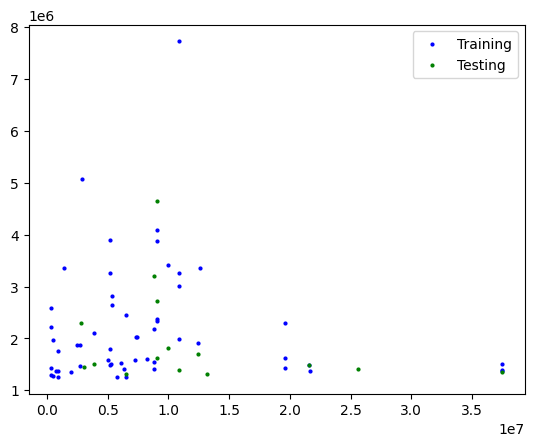

In [42]:
museums.learn(threshold=0)
museums.plot()